*This notebook is designed to tackle the classic MNIST dataset. It is a classic image classification problem with 70,000 small images of digits with their labels*

In [1]:
from sklearn.datasets import fetch_openml

mnist= fetch_openml("mnist_784", as_frame= False)

In [2]:
mnist["DESCR"]

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [3]:
mnist.categories

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}

In [4]:
mnist.target_names

['class']

In [5]:
X, y = mnist.data, mnist.target
X[:3]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [6]:
X.shape

(70000, 784)

In [7]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [8]:
y.shape

(70000,)

*Let's checkout a sample image*

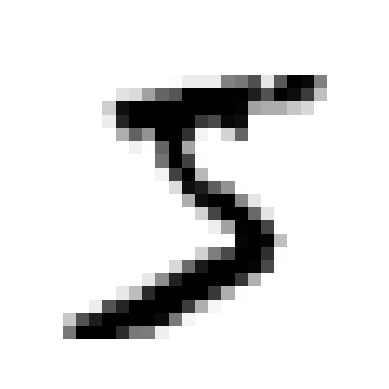

In [9]:
import matplotlib.pyplot as plt

def plot_digit(image_data, cmap= "binary"): 
    image= image_data.reshape(28,28)
    plt.imshow(image, cmap= cmap)
    plt.axis("off")

some_digit= X[0] 
plot_digit(some_digit)
plt.show()

In [10]:
some_digit_copy = X[0].reshape(28,28)

In [11]:
some_digit_copy

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [12]:
import numpy as np

xx, yy = np.meshgrid(np.arange(28), np.arange(28))
27 -yy.flatten()

array([27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27,
       27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 26, 26, 26, 26, 26,
       26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26,
       26, 26, 26, 26, 26, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25,
       25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 24,
       24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24,
       24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 21, 21,
       21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21,
       21, 21, 21, 21, 21, 21, 21, 21, 21, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 19, 19

In [13]:
xx.flatten()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,  0,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
       23, 24, 25, 26, 27,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,
       12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,  0,
        1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27,  0,  1,  2,  3,  4,  5,  6,
        7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
       24, 25, 26, 27,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,
       13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,  0,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27,  0,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
       25, 26, 27,  0,  1

In [14]:
### .imshow() under the hood

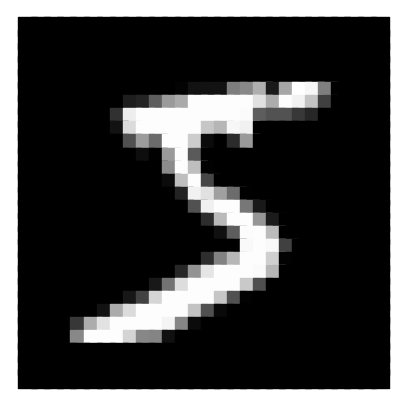

In [15]:
xx, yy = np.meshgrid(np.arange(28), np.arange(28))
plt.figure(figsize=(5,5))

plt.scatter(
    xx.flatten(),
    27 - yy.flatten(),          # Flip vertically (last pixel = 784 is bottom right (27,0) not top right (27,27)
    c=some_digit.flatten(),
    cmap="grey",
    marker="s",
    s=180
)

plt.axis("equal")
plt.axis("off")
plt.show()

In [16]:
y[0]

'5'

*Clearly a 5*

According to the DESCR, the MNIST dataset is already split into a training (first 60k instances) and test set (final 10k)

In [17]:
X_train, X_test, y_train, y_test= X[:60000], X[60000:], y[:60000], y[60000: ]

### Binary Classifier

Let's just go with a **5** or **non 5** classifier first

In [18]:
y_train_5 = (y_train == '5')
y_test_5  = (y_test == '5')

*Model 1-> **SGD Classifier***

In [19]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42) 
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [20]:
sgd_clf.predict([some_digit])

array([ True])

In [21]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv= 3, scoring = "accuracy")

array([0.95035, 0.96035, 0.9604 ])

*95% accuracy on the first shot, that's amazing innit???*

*Well.. check this out*

In [22]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier() ## Predicts the most frequent class in training
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [23]:
cross_val_score(dummy_clf, X_train, y_train_5, cv= 3, scoring ="accuracy")

array([0.90965, 0.90965, 0.90965])

*well... that should have been obvious.. only 10% of the images should actually be 5s.. so if you just go non_5s on all cases.. you're getting a 90% accuracy*

*suddenly, the 95% accuracy, does'nt look that great..*

### Accuracy Metrics

In [24]:
from sklearn.model_selection import cross_val_predict

y_train_pred= cross_val_predict(sgd_clf, X_train, y_train_5, cv= 3) ## All out of sample predicitons

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

*yeah well, more than one third of our 5s are getting falsely classified as non 5s.. can't go ahead we that, can we..*

**Precision**-> Accuracy of the +ve predictions.. (how precise are we?)  
**Recall**   -> Ratio of +ve instances actually classified correctly   

In [26]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [27]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

*Only **65%** of the 5s are actually being classified as a 5...Model does'nt look as shiny now.. huh*

In [28]:
## Understanding decison_scores and setting thresholds

In [29]:
y_scores= cross_val_predict(sgd_clf, X_train, y_train_5, cv= 3, method="decision_function")

In [30]:
y_train_5[:11]

array([ True, False, False, False, False, False, False, False, False,
       False, False])

In [31]:
y_scores[:11]

array([  1200.93051237, -26883.79202424, -33072.03475406, -15919.5480689 ,
       -20003.53970191, -16652.87731528, -14276.86944263, -23328.13728948,
        -5172.79611432, -13873.5025381 , -22112.989794  ])

*The default threshold used by SGDClassifier is set to **0**. A decsion score over that, leads to +ve prediction*

In [32]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [33]:
precisions

array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
       1.        ])

In [34]:
recalls

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       3.68935621e-04, 1.84467810e-04, 0.00000000e+00])

In [35]:
thresholds

array([-146348.56726174, -142300.00705404, -137588.97581744, ...,
         38871.26391927,   42216.05562787,   49441.43765905])

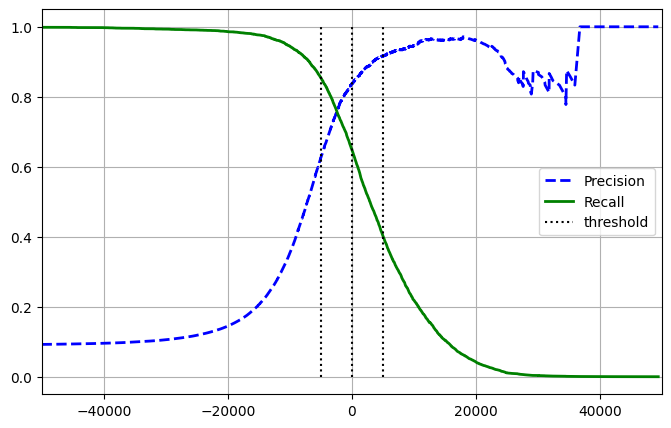

In [36]:
plt.figure(figsize= (8,5))

plt.plot(thresholds, precisions[:-1], "b--", label= "Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label= "Recall", linewidth=2)
plt.vlines([-5000, 0, 5000], 0, 1.0, "k", "dotted", label= "threshold")

plt.legend()
plt.xlim(-50000, 50000)
plt.grid()

plt.show()

*So ideally, it's between a threshold of -5k and 0, depending on what metric we value more for this case*

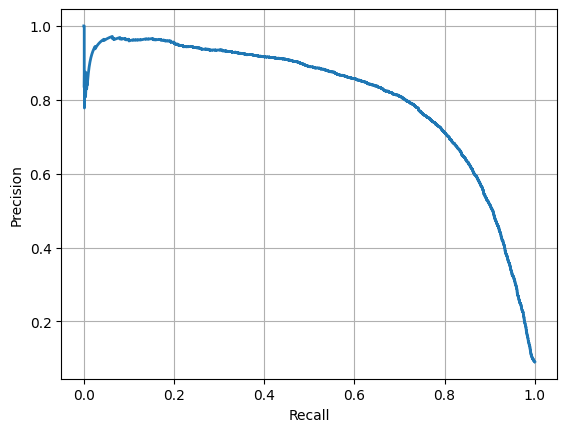

In [37]:
plt.plot(recalls, precisions, linewidth= 2, label = "Precision/Recall Curve")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()

plt.show()

In [38]:
idx_for_90_precision = (precisions>= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439557

In [39]:
y_train_pred_90 = (y_scores>= threshold_for_90_precision)

In [40]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [41]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

In [42]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds= roc_curve(y_train_5, y_scores)

In [43]:
thresholds

array([             inf,   49441.43765905,   36801.60697028, ...,
       -105763.22240074, -106527.45300471, -146348.56726174])

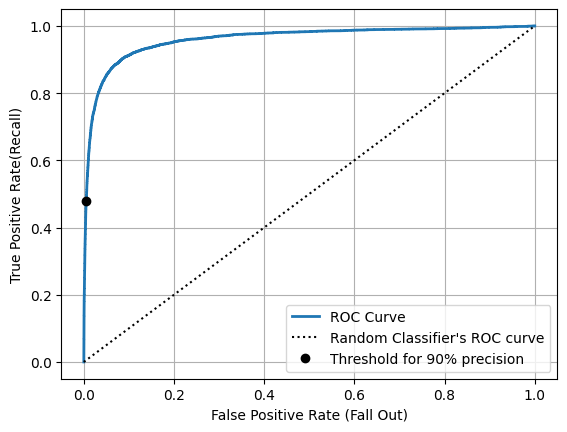

In [44]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth= 2, label = "ROC Curve")
plt.plot([0,1], [0,1], "k:", label= "Random Classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label= "Threshold for 90% precision")


plt.xlabel("False Positive Rate (Fall Out)")
plt.ylabel("True Positive Rate(Recall)")
plt.legend()
plt.grid()

plt.show()

In [45]:
from sklearn.metrics import roc_auc_score ## Gotta be maximising this.. area under roc curve
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [46]:
from sklearn.ensemble import RandomForestClassifier

forest_clf= RandomForestClassifier(random_state=42)

In [47]:
y_probas_forest= cross_val_predict(forest_clf, X_train, y_train_5, cv= 3, method = "predict_proba")

In [48]:
y_probas_forest[:5]

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       [1.  , 0.  ],
       [0.99, 0.01]])

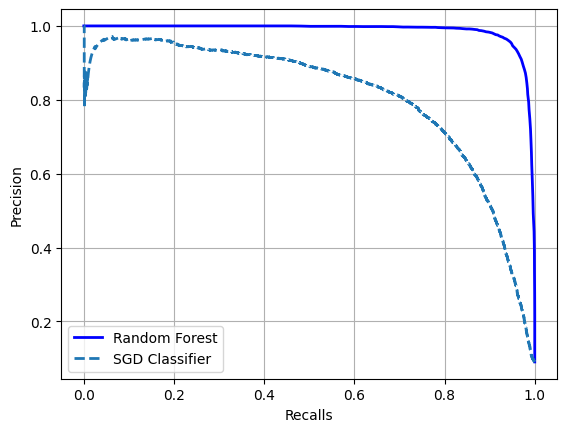

In [49]:
y_scores_forest = y_probas_forest[:, 1] ## the second col has probabilities for +ve prediction
precisions_forest, recalls_forest, thresholds_forest= precision_recall_curve(y_train_5, y_scores_forest)

plt.plot(recalls_forest, precisions_forest, "b-", linewidth = 2, label = "Random Forest")
plt.plot(recalls, precisions, "--", linewidth=  2, label ="SGD Classifier")


plt.xlabel("Recalls")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.show()

Much better, clearly

In [50]:
from sklearn.metrics import f1_score

y_train_pred_forest= y_probas_forest[:,1] >= 0.5
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [51]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

### Multiclass Classification

In [52]:
#OvR vs OvO... 

In [53]:
from sklearn.svm import SVC

svm_clf= SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

SVC(random_state=42)

In [54]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [55]:
some_digit_scores= svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [56]:
class_id = some_digit_scores.argmax()
class_id

5

In [57]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [58]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf= OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [59]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [60]:
len(ovr_clf.estimators_)

10

In [61]:
sgd_clf

SGDClassifier(random_state=42)

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf,X_train_scaled, y_train, cv=3, scoring= "accuracy")

array([0.8983, 0.891 , 0.9018])

### Error Analysis

<Figure size 640x480 with 0 Axes>

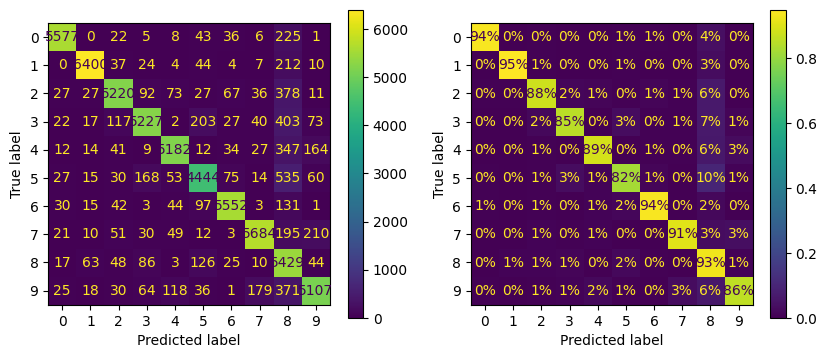

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.clf()
fig, axes= plt.subplots(1,2, figsize = (10,4))
y_train_pred= cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax= axes[0])
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize= "true", values_format=".0%", ax= axes[1])
plt.show()

with more focus on errors...

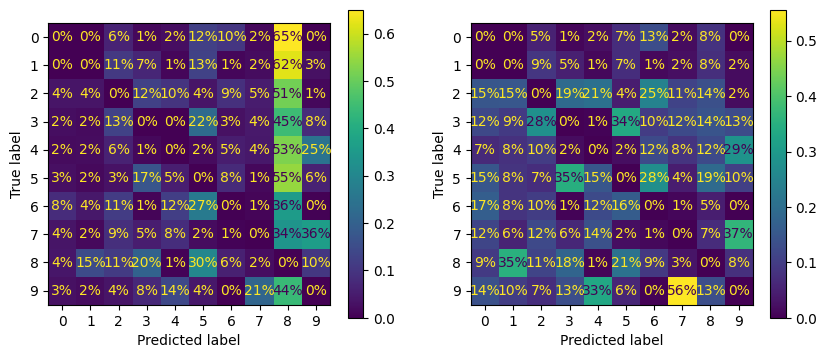

In [69]:
fig, axes= plt.subplots(1,2, figsize = (10,4))
sample_weight = (y_train_pred != y_train)

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax= axes[0], sample_weight=sample_weight, normalize= "true", values_format= ".0%")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax= axes[1], sample_weight=sample_weight,normalize= "pred", values_format=".0%")

Here, you can clearly see where the erros are actually happening.. most of the wrong predictions are when we predict 8 for something...  
the left plot is normalized acc to the true labels  (*rows*) .. so you can say 21% of *wrong classifications* of **9** are *7*...  
the right plot is normalized acc to the predictions (*cols*).. so you can say 56% of *misclassified 7s* are actually **9s**

### Multilabel Classification

Here, we want to predict multiple labels for each instance.. such as a face_recognition classifier which detects different people given any one image

In [70]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large= (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)

y_multilabel= np.c_[y_train_large, y_train_odd]

In [71]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [72]:
knn_clf.predict([some_digit])

array([[False,  True]])

*obv, 5 is not large, but it's odd*

In [73]:
y_train_knn_pred= cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average= "macro")

0.9764102655606048

### Multioutput Classification 

*Each label can be multiclass over here*

In [74]:
np.random.seed(42)

noise= np.random.randint(0,100, (len(X_train), 784))
X_train_mod= X_train + noise
noise= np.random.randint(0,100, (len(X_test), 784))
X_test_mod = X_test+ noise

In [75]:
y_train_mod = X_train
y_test_mod = X_test

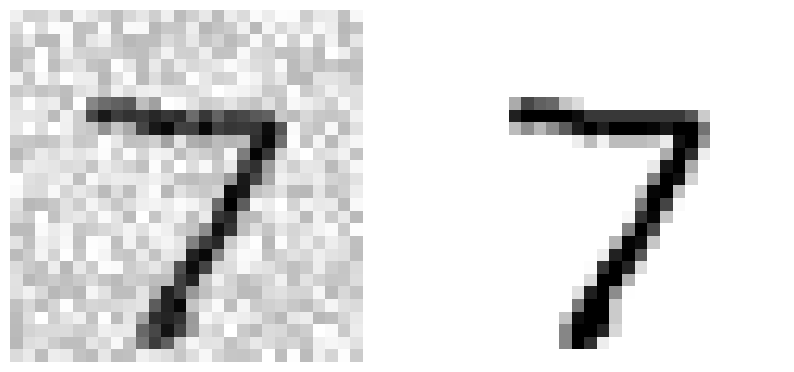

In [76]:
fig, axes= plt.subplots(1,2, figsize= (10,6))

plt.sca(axes[0])
plot_digit(X_test_mod[0])

plt.sca(axes[1])
plot_digit(y_test_mod[0])

*so that's what we gotta do, we'll send in the noisy image, and we gotta make a predicition for each pixel across 784 pixels so that we can clear the noise*

*hence, **multi-output classification***

In [78]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)

clean_digit = knn_clf.predict([X_test_mod[0]])

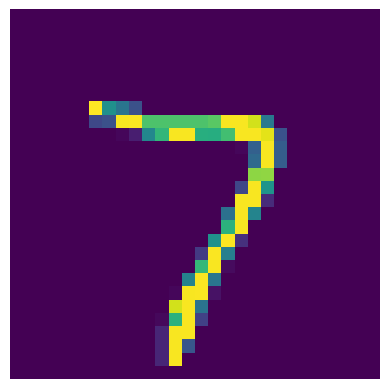

In [79]:
plot_digit(clean_digit, "viridis")
plt.show()

Hmm.. you can see it does'nt exactly match with the sample image (right image of previous plot) .. evidently, the bottom stick of 7  is more wide in the original sample than the prediction

tough to think of a cost function to measure the difference between this image generated and our sample image..  
obv, an rmse across the pixel values would be wayy too simple a cost function, not capturing the nuance

In [81]:
forest_clf

RandomForestClassifier(random_state=42)

In [83]:
forest_clf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [91]:
forest_clf.feature_importances_.shape

(784,)

(-0.5, 27.5, 27.5, -0.5)

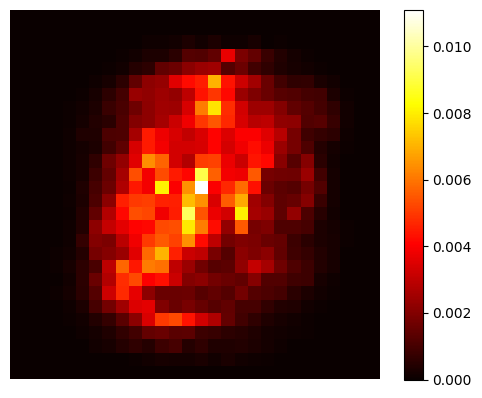

In [119]:
imp= forest_clf.feature_importances_.reshape(28,28)
plt.imshow(imp, cmap= "hot")
plt.colorbar()
plt.axis("off")

This right here, shows you the feature importances... obv the pixels towards the centre are **THE** most important